In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import io
from PIL import Image, ImageDraw, ImageFont

# PARAMETERS
input_shape = (64, 64, 3)
num_classes = 10
batch_size = 64
epochs = 40
image_size = 64
patch_size = 16
projection_dim = 128
num_heads = 8
transformer_layers = 6
num_patches = (image_size // patch_size) ** 2

# Data generators for PNG images (and jpg/jpeg, etc.) with augmentation
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen_val = ImageDataGenerator(rescale=1./255)
train_path = r'E:\cnndatasets\numbers_dataset\train'
val_path = r'E:\cnndatasets\numbers_dataset\val'

train_generator = datagen_train.flow_from_directory(
    train_path,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)
val_generator = datagen_val.flow_from_directory(
    val_path,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


# --- Vision Transformer Custom Layers ---
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dims = tf.shape(patches)[-1]
        num_patches = (image_size // patch_size) ** 2
        patches = tf.reshape(patches, [batch_size, num_patches, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
    def call(self, patches):
        return self.projection(patches)

class ClsToken(layers.Layer):
    def __init__(self, projection_dim):
        super().__init__()
        self.projection_dim = projection_dim
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.projection_dim),
            initializer='zeros',
            trainable=True,
            name='cls_token'
        )
        super().build(input_shape)
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        return tf.broadcast_to(self.cls_token, [batch_size, 1, self.projection_dim])

class AddPositionEmbs(layers.Layer):
    def __init__(self, num_tokens, projection_dim):
        super().__init__()
        self.position_embedding = layers.Embedding(input_dim=num_tokens, output_dim=projection_dim)
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        return x + self.position_embedding(positions)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation='gelu')(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def build_vit():
    inputs = layers.Input(shape=input_shape)
    x = layers.Resizing(image_size, image_size)(inputs)
    patches = Patches(patch_size)(x)
    encoded_patches = PatchEncoder(projection_dim)(patches)
    cls_token = ClsToken(projection_dim)(encoded_patches)
    x = tf.concat([cls_token, encoded_patches], axis=1)
    x = AddPositionEmbs(num_patches + 1, projection_dim)(x)
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([attention_out, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, [projection_dim*2, projection_dim], dropout_rate=0.1)
        x = layers.Add()([x3, x2])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = x[:, 0, :]
    x = layers.Dropout(0.3)(x)
    x = mlp(x, [256, 128], dropout_rate=0.3)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='vision_transformer')

model = build_vit()

# --- Optimizer & Learning Rate Schedule ---
steps_per_epoch = train_generator.samples // batch_size
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=epochs * steps_per_epoch,
    alpha=0.1
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# --- Callbacks ---
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_vit_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# --- Training ---
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)

model.load_weights('best_vit_model.keras')

# === Helper functions to save text and plots as images ===

def save_text_as_image(text, filename, font_path=None, font_size=16, padding=10):
    lines = text.split('\n')
    font = ImageFont.load_default() if font_path is None else ImageFont.truetype(font_path, font_size)
    # Calculate image size
    width = max(font.getsize(line)[0] for line in lines) + 2*padding
    height = sum(font.getsize(line)[1] for line in lines) + 2*padding
    img = Image.new('RGB', (width, height), color='white')
    draw = ImageDraw.Draw(img)
    y = padding
    for line in lines:
        draw.text((padding, y), line, font=font, fill='black')
        y += font.getsize(line)[1]
    img.save(filename)

# --- Plot and save training history ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.savefig('Vit_training_history.png')
plt.close()

# --- Save Model Summary to a text file then to image ---
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_str = stream.getvalue()
save_text_as_image(summary_str, 'Vit_model_summary.png')

# --- Final Evaluation and Report ---
val_steps = val_generator.samples // batch_size
y_pred_probs = model.predict(val_generator, steps=val_steps)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes[:len(y_pred)]
class_names = list(val_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:")
print(report)

# Save classification report as image
save_text_as_image(report, 'Vit_classification_report.png')

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.1f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('Vit_confusion_matrix.png')
plt.close()

# --- Metrics Summary ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Found 19840 images belonging to 10 classes.
Found 4960 images belonging to 10 classes.

Model: "vision_transformer"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 resizing (Resizing)         (None, 64, 64, 3)            0         ['input_1[0][0]']             
                                                                                                  
 patches (Patches)           (None, 16, 768)              0         ['resizing[0][0]']            
                                                                                                  
 patch_encoder (PatchEncode  (None, 16, 128)              98432     ['patches[0][0]']      

AttributeError: 'FreeTypeFont' object has no attribute 'getsize'

In [6]:
# Print Model Summary
model.summary()

# Print Classification Report
print("Classification Report:")
print(report)

# Plot and show Normalized Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.1f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Model: "vision_transformer"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 resizing (Resizing)         (None, 64, 64, 3)            0         ['input_1[0][0]']             
                                                                                                  
 patches_1 (Patches)         (None, 16, 768)              0         ['resizing[0][0]']            
                                                                                                  
 patch_encoder_1 (PatchEnco  (None, 16, 128)              98432     ['patches_1[0][0]']           
 der)                                                                            

NameError: name 'report' is not defined

Found 4960 images belonging to 10 classes.
77/77 [==============================] - 26s 341ms/step
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       496
           1     1.0000    0.9960    0.9980       496
           2     1.0000    1.0000    1.0000       496
           3     1.0000    1.0000    1.0000       496
           4     1.0000    1.0000    1.0000       496
           5     1.0000    1.0000    1.0000       496
           6     1.0000    1.0000    1.0000       496
           7     1.0000    1.0000    1.0000       496
           8     0.9980    1.0000    0.9990       496
           9     0.9978    1.0000    0.9989       464

    accuracy                         0.9996      4928
   macro avg     0.9996    0.9996    0.9996      4928
weighted avg     0.9996    0.9996    0.9996      4928



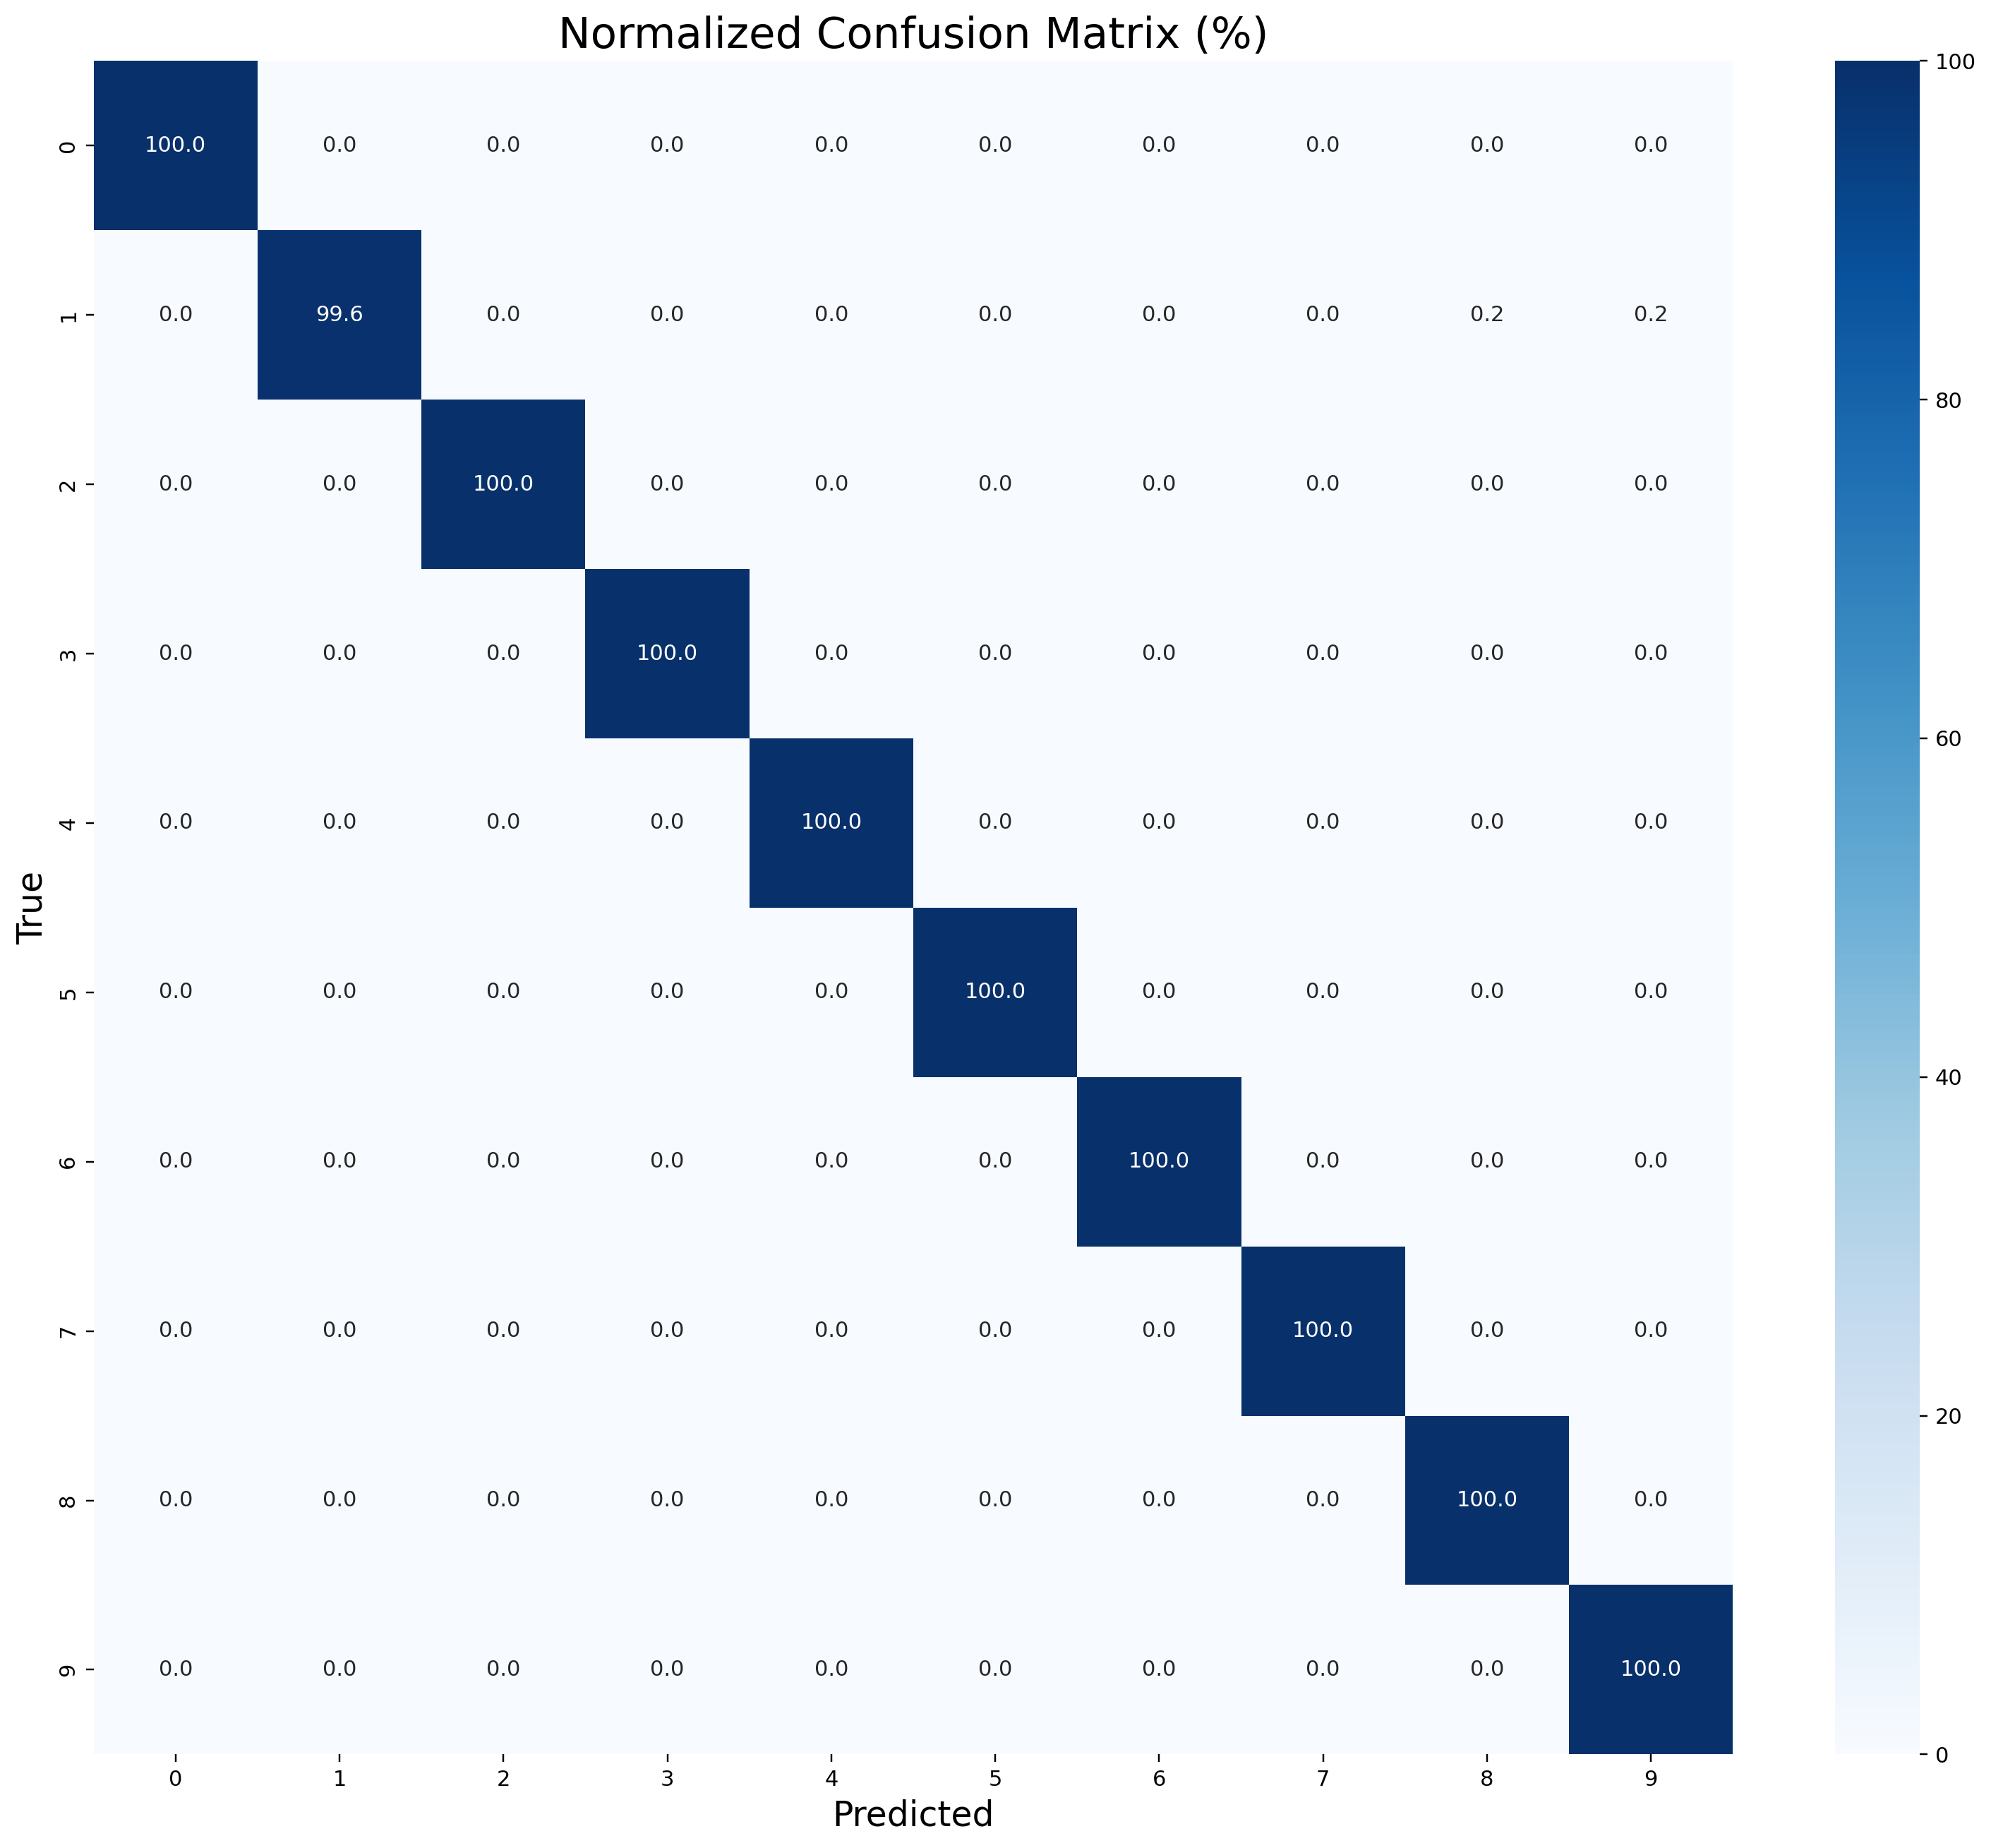

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import textwrap

# Define batch size (must match training)
batch_size = 64
val_path = r'E:\cnndatasets\numbers_dataset\val'
datagen_val = ImageDataGenerator(rescale=1./255)
val_generator = datagen_val.flow_from_directory(
    val_path,
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Helper function -- renders multiline monospaced text using matplotlib for crisp output
def save_text_matplotlib(text, filename, font_size=14, line_width=120, dpi=300, pad=0.02):
    lines = []
    for l in text.split('\n'):
        lines.extend(textwrap.wrap(l, width=line_width) or [" "])
    n_lines = len(lines)
    height_per_line = font_size * 1.5 / dpi  # Height in inches per line
    fig_height = height_per_line * n_lines + pad
    fig_width = min(max(len(max(lines, key=len)) * (font_size/12) * 0.09, 8), 48)
    plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    plt.axis('off')
    plt.figtext(0, 1-pad, "\n".join(lines), wrap=True,
                fontfamily='monospace', fontsize=font_size, va="top", ha="left")
    plt.savefig(filename, bbox_inches='tight', dpi=dpi, pad_inches=pad, transparent=False)
    plt.close()

# Save model summary as readable image
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_str = stream.getvalue()
save_text_matplotlib(summary_str, 'Vit_model_structure.png', font_size=13, line_width=130)

# Generate predictions etc.
val_steps = val_generator.samples // batch_size
y_pred_probs = model.predict(val_generator, steps=val_steps)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes[:len(y_pred)]
class_names = list(val_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n", report)
save_text_matplotlib(report, 'Vit_classification_report.png', font_size=18, line_width=100)

# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot and save confusion matrix (high resolution)
plt.figure(figsize=(14, 12), dpi=220)
sns.heatmap(cm_norm, annot=True, fmt='.1f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Normalized Confusion Matrix (%)', fontsize=20)
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.tight_layout()
plt.savefig('Vit_confusion_matrix.png')
plt.show()
